<a href="https://colab.research.google.com/github/samreenfathima18/Guvi-Final-project/blob/main/Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Define Results Path**

In [ ]:
RESULTS_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/results/"

**Load Metrics Files**

In [ ]:
linear = pd.read_csv(RESULTS_PATH + "linear_regression_metrics.csv")

catboost = pd.read_csv(RESULTS_PATH + "CatBoost_metrics.csv")

xgboost = pd.read_csv(RESULTS_PATH + "XGBoost_metrics.csv")

lightgbm = pd.read_csv(RESULTS_PATH + "LightGBM_metrics.csv")

lstm = pd.read_csv(RESULTS_PATH + "lstm_metrics.csv")

**Combine All Metrics**

In [ ]:
comparison = pd.concat(
    [
        linear,
        catboost,
        xgboost,
        lightgbm,
        lstm
    ],
    ignore_index=True
)

comparison

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,1.053811,2.134851,59.378500,0.636731
1,CatBoost,1.020661,2.039456,57.738684,0.668471
2,XGBoost,1.015759,2.044782,57.551567,0.666737
3,LightGBM,1.013185,2.024918,57.329589,0.673180
4,Enterprise LSTM,2.059405,4.293195,130.903950,0.580168


**Save Combined Results**

In [ ]:
comparison.to_csv(
    RESULTS_PATH + "model_comparison.csv",
    index=False
)

print("✅ Model comparison saved successfully!")

✅ Model comparison saved successfully!


**Model Ranking**

In [ ]:
ranking = comparison.sort_values(
    by="R2",
    ascending=False
)

ranking.reset_index(drop=True, inplace=True)

ranking

,Model,MAE,RMSE,MAPE,R2
0,LightGBM,1.013185,2.024918,57.329589,0.673180
1,CatBoost,1.020661,2.039456,57.738684,0.668471
2,XGBoost,1.015759,2.044782,57.551567,0.666737
3,Linear Regression,1.053811,2.134851,59.378500,0.636731
4,Enterprise LSTM,2.059405,4.293195,130.903950,0.580168


**Save Ranking**

In [ ]:
ranking.to_csv(
    RESULTS_PATH + "model_ranking.csv",
    index=False
)

print("✅ Model ranking saved!")

✅ Model ranking saved!


**MAE Comparison**

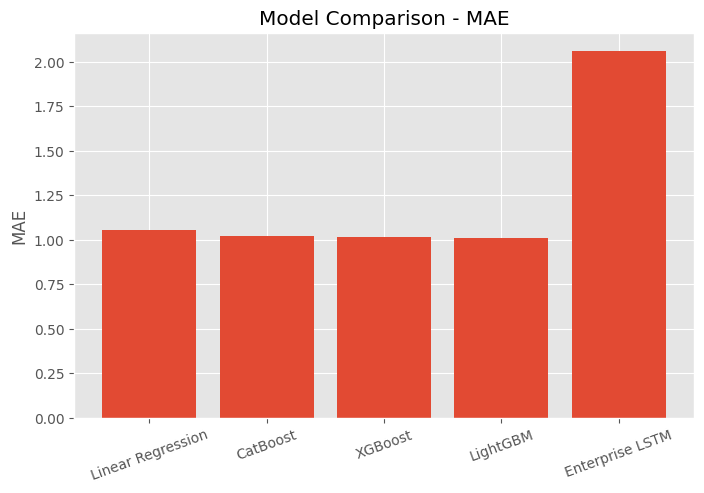

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.title("Model Comparison - MAE")
plt.ylabel("MAE")
plt.xticks(rotation=20)

plt.show()

**RMSE Comparison**

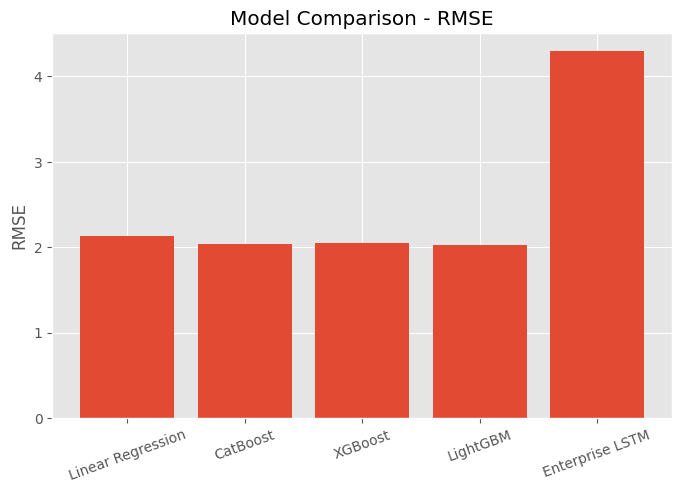

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=20)

plt.show()

**MAPE Comparison**

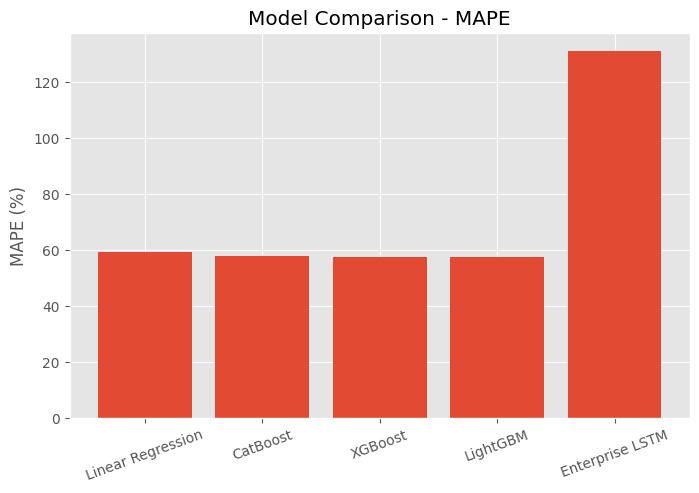

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["MAPE"]
)

plt.title("Model Comparison - MAPE")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=20)

plt.show()

**R² Comparison**

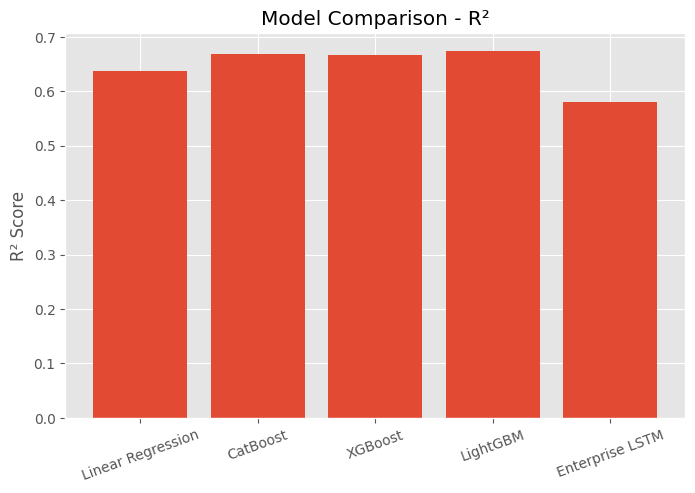

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.title("Model Comparison - R²")
plt.ylabel("R² Score")
plt.xticks(rotation=20)

plt.show()

**Best Model**

In [ ]:
best_model = comparison.loc[comparison["R2"].idxmax()]

print("=" * 50)
print("🏆 Best Model")
print("=" * 50)
print(best_model)

🏆 Best Model
Model     LightGBM
MAE       1.013185
RMSE      2.024918
MAPE     57.329589
R2         0.67318
Name: 3, dtype: object


**Performance Summary**

In [ ]:
print("=" * 50)
print("Model Ranking")
print("=" * 50)

for i, row in ranking.iterrows():
    print(
        f"{i+1}. {row['Model']} | "
        f"R² = {row['R2']:.4f} | "
        f"MAE = {row['MAE']:.4f}"
    )

Model Ranking
1. LightGBM | R² = 0.6732 | MAE = 1.0132
2. CatBoost | R² = 0.6685 | MAE = 1.0207
3. XGBoost | R² = 0.6667 | MAE = 1.0158
4. Linear Regression | R² = 0.6367 | MAE = 1.0538
5. Enterprise LSTM | R² = 0.5802 | MAE = 2.0594


**Business Insights**

**LightGBM** achieved the highest R² score and the lowest forecasting error, making it the preferred model for deployment.

**CatBoost and XGBoost** also performed strongly and can serve as alternative production models.

**Linear Regression** provided a simple and interpretable baseline but was less accurate than the ensemble models.

**The Enterprise LSTM** captured temporal demand patterns but did not outperform the tree-based algorithms on this feature-engineered dataset.

**Based on the evaluation metrics**, LightGBM is recommended for demand forecasting, inventory optimization, and executive decision-making within the Enterprise Retail Intelligence Platform.